<a href="https://colab.research.google.com/github/HaarishaH/DeepLearning_Projects/blob/main/ChurnModeling_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow

In [ ]:
import tensorflow as tf

print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [ ]:

dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## devide the dataset into independent and dependent features
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]


In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
## Feature engineering

geography = pd.get_dummies(X['Geography'],dtype=int, drop_first = True)
gender = pd.get_dummies(X['Gender'],dtype=int, drop_first = True)

In [ ]:
## Concatenete these variables with df
## axis  = 1 - column drop

X= X.drop(['Geography','Gender'], axis = 1)

In [ ]:
pd.concat([X,geography,gender],axis = 1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [ ]:
## Splitting the ds to train and test

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.30102557, -1.37744033, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.94312892, -1.031415  , ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521, -0.08179119,  1.39076231, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.87525072, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.32472465]])

In [ ]:
X.shape

(10000, 8)

In [ ]:
### Creating ANN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU,ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
### initiallize ANN

classifier = Sequential()

In [ ]:
## adding input layer, activaion will be applied in teh next layer of teh input layer
classifier.add(Dense(units=11,activation= 'relu'))

In [ ]:
# adding teh HL1
classifier.add(Dense(units = 7,activation= 'relu'))
classifier.add(Dropout(0.2))

In [ ]:
# adding teh HL2
classifier.add(Dense(units = 6,activation= 'relu'))
classifier.add(Dropout(0.3))

In [ ]:
## adding the ouptupt layer
classifier.add(Dense(1,activation= 'sigmoid'))

In [ ]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)


In [ ]:
## erly stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.0001,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [ ]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7949 - loss: 0.5816 - val_accuracy: 0.7955 - val_loss: 0.5118
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.5218 - val_accuracy: 0.7955 - val_loss: 0.4840
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.5048 - val_accuracy: 0.7955 - val_loss: 0.4785
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7962 - loss: 0.4899 - val_accuracy: 0.7955 - val_loss: 0.4753
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7962 - loss: 0.4888 - val_accuracy: 0.7955 - val_loss: 0.4723
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4912 - val_accuracy: 0.7955 - val_loss: 0.4748
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4848 - val_accuracy: 0.7955 - val_loss: 0.4746
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7962 - loss: 0.4865 - 

In [ ]:
model_history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

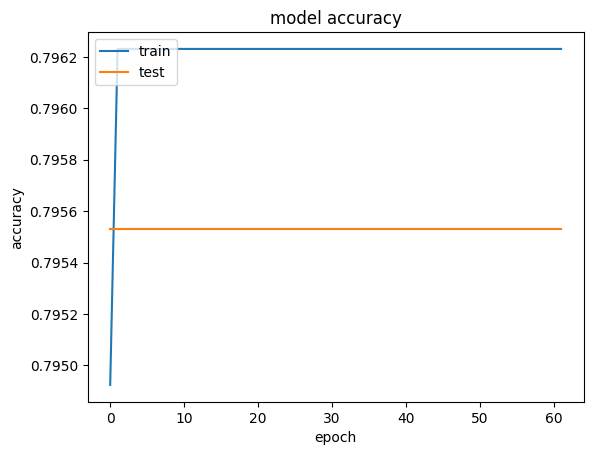

In [ ]:
#summary history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
print(len(model_history.history['accuracy']))
print(len(model_history.history['val_accuracy']))

62
62


In [ ]:
## making predictions and evaluating the model

# predicting the test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
## make the confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1595,    0],
       [ 405,    0]])

In [ ]:
## calculate the accuracy

from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)

In [ ]:
score

0.7975

In [ ]:
##get teh weights

classifier.get_weights()

[array([[-0.34776673,  0.1241211 , -0.476154  ,  0.04325306,  0.57946193,
         -0.15331484,  0.2762703 ,  0.01779551, -0.17161302, -0.06858701,
         -0.10271562],
        [-0.42421576,  0.16645005, -0.28173736,  0.60716784,  0.40142882,
         -1.3216492 , -0.8544345 ,  0.08035395,  0.1301726 , -1.4256362 ,
          0.5668784 ],
        [ 0.4263988 , -0.11653334, -0.85349154,  0.12140618,  0.0648106 ,
         -0.32525313,  0.17148045,  0.03314828,  0.33501416, -0.1312104 ,
          0.09621787],
        [-0.49830928, -0.6634911 , -0.4474756 , -0.30367953, -0.3355034 ,
          0.14188202,  0.21179947, -0.5549268 ,  0.0876317 ,  0.6063083 ,
         -0.3562743 ],
        [ 0.8598354 ,  0.93619376,  0.00189236, -0.35980958,  0.30289763,
          0.07531539, -0.90765435,  1.1541469 , -0.3257172 ,  0.15813103,
         -0.19796239],
        [-0.19082831,  0.13085853, -0.3091151 ,  0.39188412,  0.4510431 ,
          0.22093019, -0.10389714,  0.03340774, -0.47193995, -0.1685432